In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##  1.. Data Collection !

In [2]:
import os
working_directory = os.getcwd()

In [3]:
print(working_directory)

/Users/sameersuman/Documents/StockMarketAnalysis


In [4]:
path = working_directory + '/individual_stocks_5yr/*csv'

In [6]:
import glob

In [7]:
glob.glob(path)

['/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/XRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/SPGI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/MTB_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/V_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/CTAS_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/ESRX_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/APH_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/BBT_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/RHI_data.csv',
 '/Users/sameersuman/Documents/StockMarketAnalysis/individual_stocks_5yr/GGP_data.csv',
 '/Users/sameersuman/Documents/S

In [9]:
len(glob.glob(path)) ## total files we have 

505

In [ ]:
# lets store filesof those stock that we have to consider for analysis ..

In [10]:
company_list = [
   working_directory + '/individual_stocks_5yr/AAPL_data.csv' , 
   working_directory + '/individual_stocks_5yr/AMZN_data.csv' , 
   working_directory + '/individual_stocks_5yr/GOOG_data.csv' , 
    working_directory + '/individual_stocks_5yr/MSFT_data.csv'  
]

In [13]:
## use Warnings package to get rid of any future warning ..

import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
## Combine data from multiple sources into a single dataset

In [15]:
all_data = pd.DataFrame()

for file in company_list:
    
    current_df = pd.read_csv(file)

    # The commented line was actually the correct approach
    all_data = pd.concat([current_df, all_data], ignore_index=True)  

In [16]:
all_data.shape ## dimensions of all_data dataframe ..

(4752, 7)

In [17]:
all_data.head() ## top 5 rows of all_data dataframe ..

,date,open,high,low,close,volume,Name
0,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [18]:
all_data['Name'].unique()

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

## DATA CLEANING & PREPARATIONS

In [19]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')

In [20]:
all_data.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object

In [21]:
all_data['date'] = pd.to_datetime(all_data['date']) ## convert date column to datetime format ..

In [22]:
all_data.dtypes

date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object

In [23]:
all_data['date']

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
4747   2018-02-01
4748   2018-02-02
4749   2018-02-05
4750   2018-02-06
4751   2018-02-07
Name: date, Length: 4752, dtype: datetime64[ns]

In [24]:
all_data.isnull().sum() ## check for null values in all_data dataframe ..

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [25]:
all_data.duplicated().sum() ## check for duplicate values in all_data dataframe ..

np.int64(0)

In [27]:
df=all_data['volume']<0 ## check for negative values in volume column of all_data dataframe ..

In [28]:
all_data[df] ## display rows where volume is negative ..

,date,open,high,low,close,volume,Name


In [29]:
tech_list = all_data['Name'].unique()

In [30]:
tech_list

array(['MSFT', 'GOOG', 'AMZN', 'AAPL'], dtype=object)

In [31]:
all_data = all_data.sort_values(by=['Name', 'date']) ## sort all_data dataframe by Name and date column in ascending order ..

## EDA
## 2.TIME SERIES ANALYSIS
## Analysing change in price of the stock overtime !

In [32]:
all_data

,date,open,high,low,close,volume,Name
3493,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
3494,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
3495,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3496,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
3497,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
1254,2018-02-01,94.7900,96.0700,93.5813,94.2600,47227882,MSFT
1255,2018-02-02,93.6400,93.9700,91.5000,91.7800,47867753,MSFT
1256,2018-02-05,90.5600,93.2400,88.0000,88.0000,51031465,MSFT
1257,2018-02-06,86.8900,91.4750,85.2500,91.3300,67998564,MSFT


In [ ]:
## which is the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ?

In [35]:
all_data["daily_return"]=all_data.groupby('Name')['close'].pct_change() ## calculate daily return for each stock by taking percentage change of close price ..


In [37]:
risk = all_data.groupby('Name')['daily_return'].std() ## calculate standard deviation of daily return for each stock to measure volatility ..

In [38]:
risk.sort_values() ## sort risk values in ascending order to find the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

Name
GOOG    0.014069
MSFT    0.014210
AAPL    0.014593
AMZN    0.018235
Name: daily_return, dtype: float64

In [40]:
safest_stock = risk.idxmin() ## find the stock with minimum risk value to identify the safest stock to invest in among these 4 stocks based on the volatility of the stock price over the 5 year period ..

In [42]:
safest_stock

'GOOG'

## 3. TOTAL RETURN ANALYSIS
## Which stock made the highest money?

In [55]:
## Calculate total return for each stock (from first day to last day)
total_returns = {}

for stock in tech_list:
    stock_data = all_data[all_data['Name'] == stock].sort_values('date')
    first_price = stock_data['close'].iloc[0]
    last_price = stock_data['close'].iloc[-1]
    total_return = ((last_price - first_price) / first_price) * 100
    total_returns[stock] = total_return

# Display results sorted by total return (highest first)
sorted_returns = sorted(total_returns.items(), key=lambda x: x[1], reverse=True)

print("="*50)
print("TOTAL RETURN BY STOCK (5-Year Period)")
print("="*50)
for stock, return_pct in sorted_returns:
    print(f"{stock}: {return_pct:+.2f}%")

best_stock = sorted_returns[0][0]
best_return = sorted_returns[0][1]
print("="*50)
print(f"\n✓ {best_stock} made the highest money with a {best_return:.2f}% return!")

TOTAL RETURN BY STOCK (5-Year Period)
AMZN: +440.86%
MSFT: +225.26%
AAPL: +135.12%
GOOG: +87.76%

✓ AMZN made the highest money with a 440.86% return!


4.Which stock made the highest money??

In [56]:
all_data["cumulative_return"] = (1+all_data["daily_return"]).groupby(all_data['Name']).cumprod() ## calculate cumulative return for each stock by taking cumulative product of (1 + daily return) for each stock ..

In [57]:
final_returns = all_data.groupby('Name')["cumulative_return"].last() ## get the last value of cumulative return for each stock to find the total cumulative return for each stock over the 5 year period ..

final_returns.sort_values(ascending=False) ## sort final returns in descending order to find the stock with highest cumulative return over the 5 year period ..

Name
AMZN    5.408589
MSFT    3.252632
AAPL    2.351218
GOOG    1.877628
Name: cumulative_return, dtype: float64

In [58]:
best_stock = final_returns.idxmax()
best_stock

'AMZN'

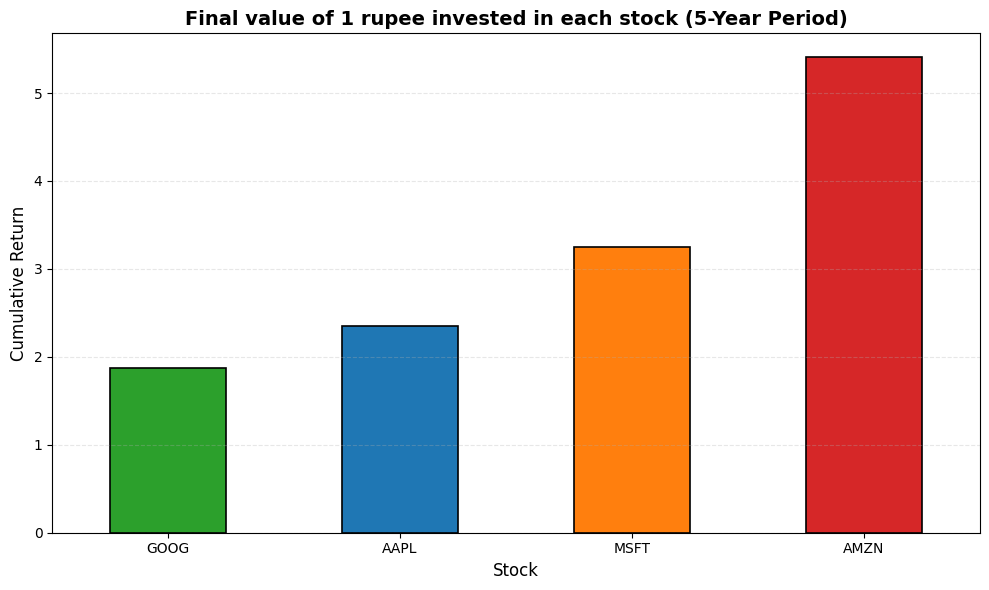

In [59]:
## Plot bar chart of final returns (ascending order)
plt.figure(figsize=(10, 6))
final_returns.sort_values().plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], edgecolor='black', linewidth=1.2)
plt.title('Final value of 1 rupee invested in each stock (5-Year Period)', fontsize=14, fontweight='bold')
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

5. 1 lakh/million SAFE INVESTMENT SIMULATION

In [60]:
best_stock = final_returns.idxmax()
best_stock

'AMZN'

In [61]:
investment = 1000000

In [63]:
df_best = all_data[all_data['Name'] == best_stock]

In [64]:
df_best

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
2234,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN,NaN,NaN
2235,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN,-0.018095,0.981905
2236,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN,0.005793,0.987593
2237,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN,0.041631,1.028708
2238,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN,-0.000854,1.027830
...,...,...,...,...,...,...,...,...,...
3488,2018-02-01,1445.00,1459.88,1385.140,1390.00,9113808,AMZN,-0.041967,5.306356
3489,2018-02-02,1477.39,1498.00,1414.000,1429.95,11125722,AMZN,0.028741,5.458866
3490,2018-02-05,1402.62,1458.98,1320.720,1390.00,11494985,AMZN,-0.027938,5.306356
3491,2018-02-06,1361.46,1443.99,1351.790,1442.84,11066819,AMZN,0.038014,5.508074


In [66]:
df_best['investment_value'] = investment * df_best['cumulative_return'] 
## calculate the value of the initial investment over time by multiplying the initial investment with the cumulative return for each day ..

In [67]:
df_best['investment_value']


2234             NaN
2235    9.819049e+05
2236    9.875931e+05
2237    1.028708e+06
2238    1.027830e+06
            ...     
3488    5.306356e+06
3489    5.458866e+06
3490    5.306356e+06
3491    5.508074e+06
3492    5.408589e+06
Name: investment_value, Length: 1259, dtype: float64

In [70]:
df_best['investment_value'] .tail().values[0] ## get the final value of the initial investment after 5 years by taking the last value of the investment_value column for the best stock ..

np.float64(5306356.174842537)

In [76]:
df_best.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return', 'investment_value'],
      dtype='object')

px.line()

In [81]:
px.line(df_best,  
        x='date', 
        y='investment_value', 
        title=f'1 Million Investment Value Over Time for - {best_stock}', 
        labels={
            'date': 'Date', 
            'investment_value': 'Portfolio Value (₹)'})

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'Date=%{x}<br>Portfolio Value (₹)=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array(['2013-02-08T00:00:00.000000000', '2013-02-11T00:00:00.000000000',
                          '2013-02-12T00:00:00.000000000', ..., '2018-02-05T00:00:00.000000000',
                          '2018-02-06T00:00:00.000000000', '2018-02-07T00:00:00.000000000'],
                         dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAA+H+/iSvjIfctQfkNrhqSIy' ... 'v9PVRBFPrVg/oCVUGtyDpb06FUQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': '1 Million Investment Value Over Time for - AMZN'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Date'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Portfolio Value (₹)'}}}
})

In [ ]:
## 6. TOP 5 WORST MARKET CRASHES (Biggest Daily Losses)

In [83]:
## Find top 5 worst days (biggest daily losses) for each stock
print("="*80)
print("TOP 5 WORST MARKET CRASHES - BIGGEST DAILY LOSSES FOR EACH STOCK")
print("="*80)

for stock in tech_list:
    stock_data = all_data[all_data['Name'] == stock].sort_values('date').copy()
    
    # Get top 5 most negative daily returns
    worst_days = stock_data.nsmallest(5, 'daily_return')[['date', 'close', 'daily_return']]
    
    print(f"\n📉 {stock} - TOP 5 WORST TRADING DAYS:")
    print(f"{'-'*76}")
    print(f"{'Rank':<6} {'Date':<12} {'Close Price':<15} {'Daily Loss':<20}")
    print(f"{'-'*76}")
    
    for idx, (i, row) in enumerate(worst_days.iterrows(), 1):
        loss_pct = row['daily_return'] * 100
        print(f"{idx:<6} {str(row['date'].date()):<12} ${row['close']:<14.2f} {loss_pct:>7.2f}%")
    
    # Summary stats
    avg_loss = worst_days['daily_return'].mean() * 100
    worst_loss = worst_days['daily_return'].min() * 100
    print(f"{'-'*76}")
    print(f"Average Loss (Top 5 days):  {avg_loss:.2f}%")
    print(f"Worst Single Day Loss:      {worst_loss:.2f}%")
    print()

print("="*80)

TOP 5 WORST MARKET CRASHES - BIGGEST DAILY LOSSES FOR EACH STOCK

📉 MSFT - TOP 5 WORST TRADING DAYS:
----------------------------------------------------------------------------
Rank   Date         Close Price     Daily Loss          
----------------------------------------------------------------------------
1      2013-07-19   $31.40           -11.40%
2      2015-01-27   $42.66            -9.25%
3      2016-04-22   $51.78            -7.17%
4      2015-08-21   $43.07            -5.67%
5      2013-09-03   $31.88            -4.55%
----------------------------------------------------------------------------
Average Loss (Top 5 days):  -7.61%
Worst Single Day Loss:      -11.40%


📉 GOOG - TOP 5 WORST TRADING DAYS:
----------------------------------------------------------------------------
Rank   Date         Close Price     Daily Loss          
----------------------------------------------------------------------------
1      2016-04-22   $718.77           -5.32%
2      2015-08-21   $6